# seed iteration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, roc_curve

In [ ]:
# Load Data
X = pd.read_csv("./modeling_counts_cpm_tmm_log.csv", index_col=0).T
# X = pd.read_csv("/fs/cbsuvlaminck5/workdir/gfa32/hsct_new/1_DATA/corrected_expr_platelet.tsv", sep = "\t", index_col=0).T

metadata = pd.read_csv("./modeling_metadata.csv", index_col="sample_id")

# Extract y (expGroup) and ORIGIN
y = metadata["expGroup"]
origin = metadata["ORIGIN"]

# Create a stratification column combining expGroup & ORIGIN
metadata["stratify_group"] = metadata["expGroup"].astype(str) + "_" + metadata["ORIGIN"].astype(str)


In [8]:
# Store results
auc_results = []
classifier_scores_list = []
selected_features_list = []

# Run 100 iterations with different train-test splits
# for seed in range(101):
for seed in range(10):


    print(f"Iteration {seed+1}/100...")

    # Step 1: Stratified train-test split based on expGroup & ORIGIN
    cpm_train, cpm_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=metadata["stratify_group"], random_state=seed
    )

    # Step 2: Remove features where at least 75% of samples in train set have values ≤ 0.5
    mask = (cpm_train > 0.5).sum(axis=0) >= (0.75 * len(cpm_train))  # Keep features where ≥ 25% of values are > 0.5
    cpm_train_filtered = cpm_train.loc[:, mask]

    # Step 3: Subset test set to selected features
    cpm_test_filtered = cpm_test.loc[:, cpm_train_filtered.columns]

    # Step 4: Define LASSO model and cross-validation
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=seed)
    lasso = LogisticRegression(penalty="l1", class_weight="balanced", max_iter=int(1e6), solver="liblinear", random_state=seed)
    lasso_cv = GridSearchCV(lasso, param_grid={"C": np.logspace(-2, 2, 30)}, scoring="roc_auc", cv=cv, n_jobs=-1)

    # # Step 5: Preprocessing + Model Pipeline
    # preprocessing = Pipeline([
    #     ("variance", VarianceThreshold(0.5)),
    #     ("std", StandardScaler()),
    #     ("impute", SimpleImputer(strategy="median"))
    # ])
    
    pipeline = Pipeline([
        ("lasso_cv", lasso_cv)
    ])

    # Train the model
    pipeline.fit(cpm_train_filtered, y_train)

    # Step 6: Get best model and make predictions
    best_lasso = pipeline.named_steps["lasso_cv"].best_estimator_

    # Predict probabilities for train & test sets
    train_probs = best_lasso.predict_proba(cpm_train_filtered)[:, 1]
    test_probs = best_lasso.predict_proba(cpm_test_filtered)[:, 1]

    # Calculate AUC and store results
    test_auc = roc_auc_score(y_test, test_probs)
    auc_results.append(test_auc)

    ### 🔹 Save Classifier Scores (Train & Test)
    df_train = pd.DataFrame({
        "sample_id": cpm_train_filtered.index,
        "iteration": seed,
        "train_or_test": "train",
        "classifier_score": train_probs
    })

    df_test = pd.DataFrame({
        "sample_id": cpm_test_filtered.index,
        "iteration": seed,
        "train_or_test": "test",
        "classifier_score": test_probs
    })

    # Append to full classifier scores list
    classifier_scores_list.append(pd.concat([df_train, df_test]))

    ### 🔹 Save Selected Features & Coefficients
    selected_features = cpm_train_filtered.columns[best_lasso.coef_.flatten() != 0]
    selected_coefficients = best_lasso.coef_.flatten()[best_lasso.coef_.flatten() != 0]

    df_features = pd.DataFrame({
        "iteration": seed,
        "feature": selected_features,
        "coefficient": selected_coefficients
    })

    # Append to selected features list
    selected_features_list.append(df_features)

# Convert lists to DataFrames
classifier_scores_df = pd.concat(classifier_scores_list, ignore_index=True)
selected_features_df = pd.concat(selected_features_list, ignore_index=True)

# Save to CSV
classifier_scores_df.to_csv("classifier_scores.csv", index=False)
selected_features_df.to_csv("selected_features.csv", index=False)

print("\n✅ Saved classifier scores & selected features!")



Iteration 1/100...


ValueError: Found input variables with inconsistent numbers of samples: [602, 142]


Test AUC Summary:
count    101.000000
mean       0.743691
std        0.089488
min        0.539216
25%        0.691176
50%        0.754902
75%        0.803922
max        0.931373
Name: Test_AUC, dtype: float64


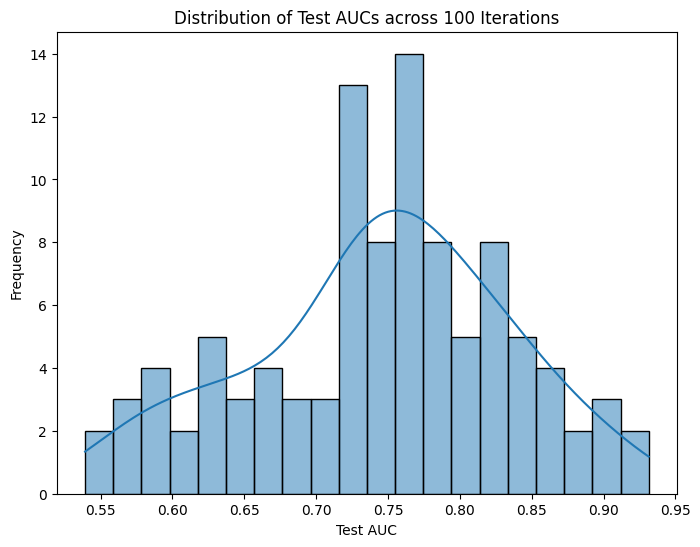

In [4]:
# Convert results to DataFrame
auc_df = pd.DataFrame({"Iteration": np.arange(1, 102), "Test_AUC": auc_results})
# auc_df = pd.DataFrame({"Iteration": np.arange(1, 11), "Test_AUC": auc_results})


# Save results to CSV
auc_df.to_csv("lasso_test_auc_results.csv", index=False)

# Print summary statistics
print("\nTest AUC Summary:")
print(auc_df["Test_AUC"].describe())

# Plot AUC Distribution
plt.figure(figsize=(8, 6))
sns.histplot(auc_df["Test_AUC"], bins=20, kde=True)
plt.xlabel("Test AUC")
plt.ylabel("Frequency")
plt.title("Distribution of Test AUCs across 100 Iterations")
plt.show()

In [5]:
median_value = auc_df["Test_AUC"].median()
median_row = auc_df[auc_df["Test_AUC"] == median_value]

median_row

,Iteration,Test_AUC
7,8,0.754902
9,10,0.754902
13,14,0.754902
49,50,0.754902
75,76,0.754902


In [ ]:
auc_df

,Iteration,Test_AUC
0,1,0.759804
1,2,0.691176
2,3,0.823529
3,4,0.627451
4,5,0.823529
...,...,...
96,97,0.671569
97,98,0.799020
98,99,0.705882
99,100,0.857843


---
---
# train & test

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer


import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
import seaborn as sns

### train lasso

In [ ]:
# Load Data
X_train = pd.read_csv("./counts_vst_train.csv", index_col=0).T
X_valid = pd.read_csv("./counts_vst_test.csv", index_col=0).T
y_train = pd.read_csv("./training_df.csv", index_col="sample_id")["expGroup"]
y_valid = pd.read_csv("./test_df.csv", index_col="sample_id")["expGroup"]

# Ensure matching feature sets
common_features = X_train.columns.intersection(X_valid.columns)
X_train, X_valid = X_train[common_features], X_valid[common_features]

# Define Cross-Validation Strategy
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

# Lasso Model with GridSearchCV
lasso = LogisticRegression(penalty="l1", class_weight="balanced", max_iter=int(1e6), solver="liblinear", random_state=42)
lasso_cv = GridSearchCV(lasso, param_grid={"C": np.logspace(-2, 2, 30)}, scoring="roc_auc", cv=cv, n_jobs=-1)


# ElasticNet
en = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    class_weight='balanced',
    max_iter=int(1e3),
    random_state=42
)
en_cv = GridSearchCV(en, param_grid={"C": np.logspace(-2, 1, 5), "l1_ratio": [.5, .7, .9]}, scoring="roc_auc", cv=cv, n_jobs=-1)



# Preprocessing Pipeline
preprocessing = Pipeline([
    ("variance", VarianceThreshold(0.5)),
    ("std", StandardScaler()),
    ("impute", SimpleImputer(strategy="median"))
])

# Full Pipeline
pipeline = Pipeline([
    # ("preprocessing", preprocessing),
    # ("lasso_cv", lasso_cv)
    ("lasso_cv", lasso_cv)
])

# Train Model
pipeline.fit(X_train, y_train)


Pipeline(steps=[('lasso_cv',
                 GridSearchCV(cv=RepeatedStratifiedKFold(n_repeats=5, n_splits=5, random_state=42),
                              estimator=LogisticRegression(class_weight='balanced',
                                                           max_iter=1000000,
                                                           penalty='l1',
                                                           random_state=42,
                                                           solver='liblinear'),
                              n_jobs=-1,
                              param_grid={'C': array([1.00000000e-02, 1.37382380e-02, 1.88739182e-02, 2.59294380e-02,
       3.56224789e-02, 4.89390092e-02,...
       1.26896100e-01, 1.74332882e-01, 2.39502662e-01, 3.29034456e-01,
       4.52035366e-01, 6.21016942e-01, 8.53167852e-01, 1.17210230e+00,
       1.61026203e+00, 2.21221629e+00, 3.03919538e+00, 4.17531894e+00,
       5.73615251e+00, 7.88046282e+00, 1.08263673e+01, 1.48735211e+01,
       2.04335972e+01, 2.80721620e+01, 3.85662042e+01, 5.29831691e+01,
       7.27895384e+01, 1.00000000e+02])},
                              scoring='roc_auc'))])

### extract features

In [ ]:
### get features

# Extract best model from GridSearchCV
best_lasso = pipeline.named_steps["lasso_cv"].best_estimator_

# Extract selected features
selected_features = X_train.columns[best_lasso.coef_.flatten() != 0]

# Save selected features to a CSV
selected_features.to_series().to_csv("selected_features.csv", index=False)

# Print selected features
print(f"Selected Features ({len(selected_features)}):")
print(selected_features.tolist())

Selected Features (110):
['ENSG00000076864.20', 'ENSG00000187010.21', 'ENSG00000126709.16', 'ENSG00000134668.12', 'ENSG00000134690.11', 'ENSG00000117410.14', 'ENSG00000162366.8', 'ENSG00000134198.10', 'ENSG00000183598.4', 'ENSG00000230426.4', 'ENSG00000260077.1', 'ENSG00000270820.6', 'ENSG00000116005.12', 'ENSG00000172005.11', 'ENSG00000169994.19', 'ENSG00000136720.7', 'ENSG00000287115.1', 'ENSG00000177917.11', 'ENSG00000115993.13', 'ENSG00000178917.17', 'ENSG00000172037.14', 'ENSG00000187098.17', 'ENSG00000163412.13', 'ENSG00000181847.12', 'ENSG00000065485.20', 'ENSG00000201413.1', 'ENSG00000113838.13', 'ENSG00000287037.1', 'ENSG00000138755.6', 'ENSG00000181004.10', 'ENSG00000109458.8', 'ENSG00000137460.10', 'ENSG00000145431.11', 'ENSG00000155542.12', 'ENSG00000281357.3', 'ENSG00000247627.2', 'ENSG00000282988.2', 'ENSG00000273802.2', 'ENSG00000204622.11', 'ENSG00000204613.11', 'ENSG00000172673.11', 'ENSG00000135540.11', 'ENSG00000106537.8', 'ENSG00000249978.1', 'ENSG00000146918.20', '

### plot results

Train AUC: 1.000
Test AUC: 0.618


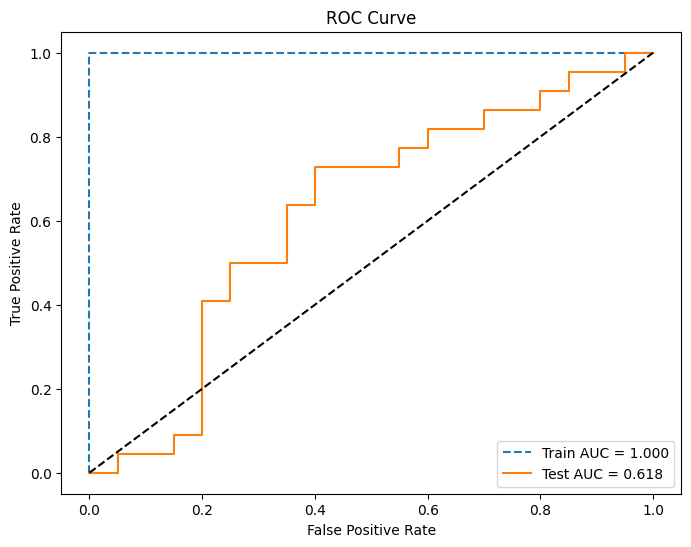

<Figure size 600x500 with 0 Axes>

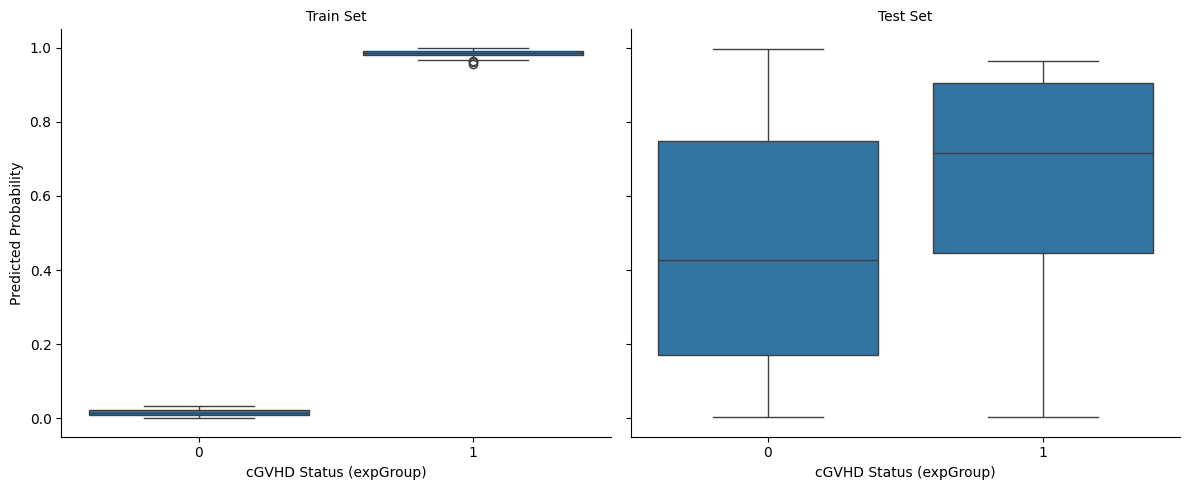

In [ ]:
# Get model and preprocessor from pipeline
best_lasso = pipeline.named_steps["lasso_cv"].best_estimator_
# preprocessor = pipeline.named_steps["preprocessing"]

# Transform data using the same preprocessing pipeline
# X_train_processed = preprocessor.transform(X_train)
# X_valid_processed = preprocessor.transform(X_valid)

X_train_processed = X_train
X_valid_processed = X_valid


# Predict probabilities
train_probs = best_lasso.predict_proba(X_train_processed)[:, 1]  # Probabilities for class 1
valid_probs = best_lasso.predict_proba(X_valid_processed)[:, 1]

# Calculate AUC scores
train_auc = roc_auc_score(y_train, train_probs)
valid_auc = roc_auc_score(y_valid, valid_probs)

print(f"Train AUC: {train_auc:.3f}")
print(f"Test AUC: {valid_auc:.3f}")

# --- ROC Curve ---
plt.figure(figsize=(8, 6))
fpr_train, tpr_train, _ = roc_curve(y_train, train_probs)
fpr_valid, tpr_valid, _ = roc_curve(y_valid, valid_probs)

plt.plot(fpr_train, tpr_train, label=f"Train AUC = {train_auc:.3f}", linestyle="--")
plt.plot(fpr_valid, tpr_valid, label=f"Test AUC = {valid_auc:.3f}", linestyle="-")

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random classifier
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# --- Boxplot of Classifier Scores ---
plt.figure(figsize=(6, 5))
# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    "expGroup": np.concatenate([y_train, y_valid]),  # 0 or 1 labels
    "probability": np.concatenate([train_probs, valid_probs]),
    "dataset": ["Train"] * len(y_train) + ["Test"] * len(y_valid)
})

# Convert expGroup to categorical for better plotting
plot_df["expGroup"] = plot_df["expGroup"].astype(str)

# Create a FacetGrid for separate Train/Test boxplots
g = sns.FacetGrid(plot_df, col="dataset", sharey=True, height=5, aspect=1.2)
g.map_dataframe(sns.boxplot, x="expGroup", y="probability", order=["0", "1"])

# Adjust titles
g.set_axis_labels("cGVHD Status (expGroup)", "Predicted Probability")
g.set_titles(col_template="{col_name} Set")
plt.show()

In [ ]:
import warnings
warnings.filterwarnings('ignore')

random_state = 42

---
---
# Train test old

## Libraries

In [ ]:
import numpy as np
import pandas as pd
from stabl import data
from stabl.multi_omic_pipelines import multi_omic_stabl
from sklearn.model_selection import RepeatedStratifiedKFold, GroupShuffleSplit, GridSearchCV
from sklearn.linear_model import LogisticRegression
from stabl.stabl import Stabl
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from stabl.preprocessing import LowInfoFilter
from sklearn.impute import SimpleImputer
from stabl.adaptive import ALogitLasso
from sklearn.base import clone
import warnings

inner_group_cv = GroupShuffleSplit(n_splits=25, test_size=0.2, random_state=42)
chosen_inner_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

## Load data

In [ ]:
X_train_cgvhd = pd.read_csv("./counts_vst_train.csv",index_col=0).T
X_valid_cgvhd = pd.read_csv("./counts_vst_test.csv",index_col=0).T
y_train_cgvhd = pd.read_csv("./training_df.csv",index_col="sample_id").loc[:,"expGroup"]
y_valid_cgvhd = pd.read_csv("./test_df.csv",index_col="sample_id").loc[:,"expGroup"]
ids = pd.read_csv("./training_df.csv",index_col="sample_id").loc[:,"Record_ID"]
task_type = "binary"

X_train_cgvhd.index.name = "sample_id"

X_train_cgvhd = {
    "CFRNA": X_train_cgvhd
}
X_valid_cgvhd = {
    "CFRNA": X_valid_cgvhd
}

common_indices = X_train_cgvhd["CFRNA"].index.intersection(y_train_cgvhd.index)
common_features = X_train_cgvhd["CFRNA"].columns.intersection(X_valid_cgvhd["CFRNA"].columns)

## Establish pipeline

In [ ]:
inner_group_cv = GroupShuffleSplit(n_splits=25, test_size=0.2, random_state=42)
chosen_inner_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

artificial_type = "random_permutation"

# Lasso
lasso = LogisticRegression(penalty="l1", class_weight="balanced", max_iter=int(1e6), solver="liblinear", random_state=42)
lasso_cv = GridSearchCV(lasso, param_grid={"C": np.logspace(-2, 2, 30)}, scoring="roc_auc", cv=chosen_inner_cv, n_jobs=-1)

# ElasticNet
en = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    class_weight='balanced',
    max_iter=int(1e3),
    random_state=42
)

# Stabl
stabl = Stabl(
    base_estimator=lasso,
    n_bootstraps=200,
    artificial_type=artificial_type,
    artificial_proportion=1,
    replace=False,
    fdr_threshold_range=np.arange(0.1, 1, 0.01),
    sample_fraction=0.5,
    random_state=42,
    lambda_grid={"C": np.linspace(0.01, 1, 30)},
    verbose=1
)

# Stabl en
stabl_en = clone(stabl).set_params(
    base_estimator=en,
    n_bootstraps=100,
    lambda_grid=[
        {"C": np.logspace(-3, -1, 10), "l1_ratio": [0.9]}
    ],
    verbose=1
)


preprocessing = Pipeline(
    steps=[
        ("variance", VarianceThreshold(0.5)),
        ("lif", LowInfoFilter()),
        ("std", StandardScaler()),
        ("impute", SimpleImputer(strategy="median"))
    ]
)

In [ ]:
overall_pipe = Pipeline(
    steps=[
        # ("preprocessing", preprocessing),  # We use the preprocessing pipeline previously defined
        ("final_model", lasso_cv),  # We use Stabl for feature selection
        # ("final_model", LogisticRegression(penalty=None, max_iter=int(1e6)))  # We use Logistic Regression as final model
    ]
)

X_train = X_train_cgvhd["CFRNA"]
y_train = y_train_cgvhd

X_valid = X_valid_cgvhd["CFRNA"]
y_valid = y_valid_cgvhd

# overall_pipe.fit(X_train, y_train_cgvhd)

Pipeline(steps=[('final_model',
                 GridSearchCV(cv=RepeatedStratifiedKFold(n_repeats=5, n_splits=5, random_state=42),
                              estimator=LogisticRegression(class_weight='balanced',
                                                           max_iter=1000000,
                                                           penalty='l1',
                                                           random_state=42,
                                                           solver='liblinear'),
                              n_jobs=-1,
                              param_grid={'C': array([1.00000000e-02, 1.37382380e-02, 1.88739182e-02, 2.59294380e-02,
       3.56224789e-02, 4.89390092e-...
       1.26896100e-01, 1.74332882e-01, 2.39502662e-01, 3.29034456e-01,
       4.52035366e-01, 6.21016942e-01, 8.53167852e-01, 1.17210230e+00,
       1.61026203e+00, 2.21221629e+00, 3.03919538e+00, 4.17531894e+00,
       5.73615251e+00, 7.88046282e+00, 1.08263673e+01, 1.48735211e+01,
       2.04335972e+01, 2.80721620e+01, 3.85662042e+01, 5.29831691e+01,
       7.27895384e+01, 1.00000000e+02])},
                              scoring='roc_auc'))])

---
---
## SAVE OUTPUT

In [ ]:
y_train_preds = overall_pipe.predict_proba(X_train)[:,1]
y_valid_preds = overall_pipe.predict_proba(X_valid)[:,1]

train_results = pd.DataFrame(
        index=X_train.index,
        data=y_train_preds,
)
valid_results = pd.DataFrame(
        index=X_valid.index,
        data=y_valid_preds,
)

train_results.to_csv("train_results_STABL.csv")
valid_results.to_csv("valid_results_STABL.csv")

In [ ]:
stabl_en_model = overall_pipe.named_steps['feature_selection']
features = stabl_en_model.get_feature_names_out()
pd.DataFrame(features).to_csv("features_STABL.csv")

---
---
## Visualize

In [ ]:
from stabl.stabl import Stabl, plot_stabl_path, plot_fdr_graph, export_stabl_to_csv, save_stabl_results
from stabl.visualization import boxplot_features, scatterplot_features, plot_roc, boxplot_binary_predictions


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='1 - Specificity', ylabel='Sensitivity'>)

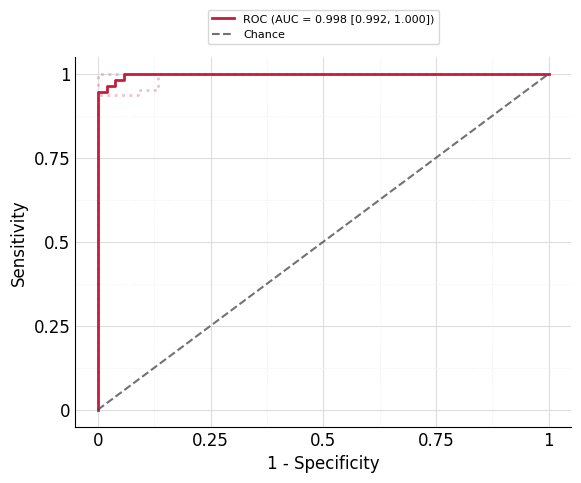

In [ ]:
plot_roc(y_train, overall_pipe.predict_proba(X_train)[:,1])


(<Figure size 550x350 with 1 Axes>,
 <Axes: title={'center': '$\\bf{AUROC}$=1.00 [0.99, 1.00]\n$\\bf{AUPRC}$=1.00 [0.99, 1.00]'}, xlabel='Predictions', ylabel='expGroup'>)

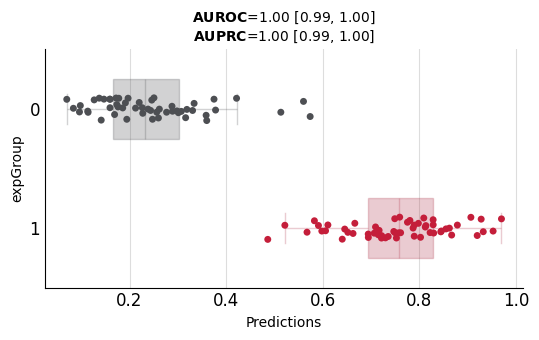

In [ ]:
boxplot_binary_predictions(y_train, overall_pipe.predict_proba(X_train)[:,1])

In [ ]:
y_valid_preds = overall_pipe.predict_proba(X_valid)[:,1]

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='1 - Specificity', ylabel='Sensitivity'>)

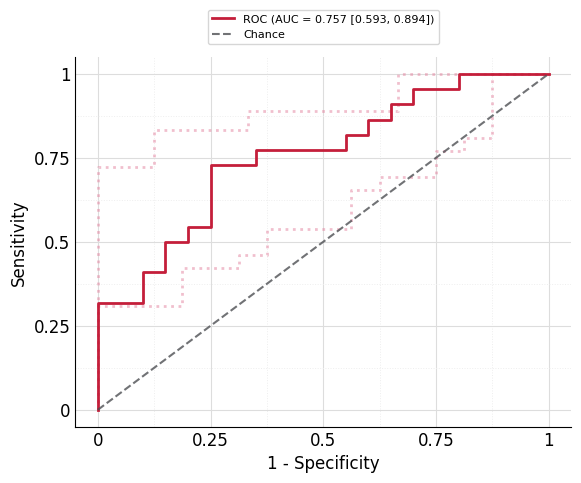

In [ ]:
plot_roc(y_valid, y_valid_preds)

(<Figure size 550x350 with 1 Axes>,
 <Axes: title={'center': '$\\bf{AUROC}$=0.76 [0.61, 0.89]\n$\\bf{AUPRC}$=0.80 [0.62, 0.91]'}, xlabel='Predictions', ylabel='expGroup'>)

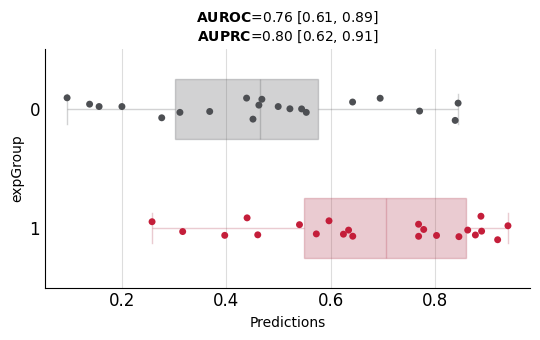

In [ ]:
boxplot_binary_predictions(y_valid, overall_pipe.predict_proba(X_valid)[:,1])